# Train/Test Unsupervised Machine Learning Classifiers

### Imports

In [1]:
# General
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import tabulate
import os

# Scikit-learn general
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

# Image Analysis
from skimage.measure import label, regionprops

# ML Model
from sklearn.cluster import KMeans

# Model and Data Preservation
import joblib
import json


# Set start time
start_time = time.time()

### Inputs

In [2]:
# Input the scan dimensions in microns
width_micron=1.0
height_micron=1.0

# Specify the path to the input folder (location of all files/data)
'''
This is the location where the processed AFM data files and feature list file
are saved.
'''
input_folder = "."


# Specify the path to the output folder (location to store saved files)
'''
This is the location in which the trained ML classifiers, fit scalers, and list of
features used in the training will be saved.
'''
output_folder = "."


# Specify the filename of the .csv file of the list of features to be used in the training
'''
This is a .csv file containing the names of the features to be used
in the ML classifier training. The first column contains the
names of the engineered features (the same names as the
column headers in the processed AFM data .csv files).
'''
feature_list_filename = "features_list.csv"


# Specify the filename of the .csv file of the training data with particle/substrate only
'''
This is a .csv file containing the feature values for each
force-distance curve in the AFM scan of the PG particles on 
the MPBA/gold substrate. Each row is a different force-distance 
curve and each column is a different feature value.
'''
data_train_particles_filename = "training_particle_substrate_feature_values.csv"


# Specify the filename of the .csv file of the training data with bare substrate only
'''
This is a .csv file containing the feature values for each
force-distance curve in the AFM scan of the MPBA/gold substrate. 
Each row is a different force-distance 
curve and each column is a different feature value.
'''
data_train_substrate_filename = "training_substrate_only_feature_values.csv"


# Define font properties for all plots
font = {'size': 20, 'weight': 'normal'}
plt.rc('font', **font)

### Functions

In [3]:
# Define a function to plot classification plots    
def plot_afm_classification(image_data, width_micron, height_micron, title = "AFM Image"):
    
    plt.figure(figsize=(10, 8))
    extent = [0, width_micron, 0, height_micron]  # [xmin, xmax, ymin, ymax]
    
    plt.imshow(image_data, cmap="gray", extent=extent)
    plt.xlabel("µm")
    plt.title(title)
    
    cbar = plt.colorbar(label="Classification")
    cbar.set_ticks([0, 1])
    
    plt.show()

### Import training/testing data for each force-distance curve

In [4]:
#----- Import Force-distance Curve data and manual labels -----#

# Read the .csv file into a DataFrame
file_path_data_train_particles = os.path.join(input_folder, data_train_particles_filename)
df_data_train_particles = pd.read_csv(file_path_data_train_particles)

# Read the .csv file into a DataFrame
file_path_data_train_substrate = os.path.join(input_folder, data_train_substrate_filename)
df_data_train_substrate = pd.read_csv(file_path_data_train_substrate)

# Combine the data from the two AFM measurements
df_all_data = pd.concat([df_data_train_particles, df_data_train_substrate])

### Import Feature List to Use

In [5]:
#----- Import list of features to use -----#

# Load the .csv file into a DataFrame
file_path_feature_list = os.path.join(input_folder, feature_list_filename)
features_selected_df_all = pd.read_csv(file_path_feature_list)
# extract the first column (feature names)
features_selected_df = features_selected_df_all.iloc[:, [0]] 
# convert the 'Feature' column as a list
selected_features = features_selected_df['Feature'].tolist()

# display feature list information
print("Features loaded successfully as list:")
print(selected_features)
print('Number of selected features:', len(selected_features))

Features loaded successfully as list:
['Deformation from 2% to 5% of max force', 'Deformation from 2% to 25% of max force', 'Deformation from 2% to 50% of max force', 'Deformation from 2% to 75% of max force', 'Deformation from 2% to 100% of max force', 'Deformation from 5% to 25% of max force', 'Deformation from 5% to 50% of max force', 'Deformation from 5% to 75% of max force', 'Deformation from 5% to 100% of max force', 'Deformation from 25% to 50% of max force', 'Deformation from 25% to 75% of max force', 'Deformation from 25% to 100% of max force', 'Deformation from 50% to 75% of max force', 'Deformation from 50% to 100% of max force', 'Deformation from 75% to 100% of max force', 'Stiffness at max force', "Young's modulus (10 nm indentation)", "Young's modulus (entire deformation)", 'Recovery from 5% to 2% of max force', 'Recovery from 25% to 2% of max force', 'Recovery from 50% to 2% of max force', 'Recovery from 75% to 2% of max force', 'Recovery from 100% to 2% of max force', '

### Create a dataframe of selected feature values for each force-distance curve

In [6]:
# Set up the features and target
start_feature = 'data_ext_deformation_5p_minus_2p_vector (nm)' # this is the first feature value column in df_all_data
stop_feature = 'data_adhesion_energy_width_vector (nm)' # this is the last feature value column in df_all_data
target_feature = 'label' # this is the name of the column that indicates the manually labelled classifications

# Manual labels are 0, 1, or 2 to indicate substrate, outer region, inner region respectively
# Create a binary classification DataFrame between the particles and the substrate for the particle/substrate ML classifier
y_1 = df_all_data[target_feature].copy()
# Change all pixels classified with a label of nonzero to 1 (i.e. change 2's to 1's) 
y_1[y_1 != 0] = 1

# Create a dataframe of all feature value for the selected features
X = df_all_data.loc[:, selected_features]



## Particle/Substrate ML Classifer

### Train/Test the Particle/Substrate ML Classifier

In [7]:
# Train-test split with 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X, y_1, test_size=0.2, random_state=17)

# Scale the data: fit only on training set
scaler_1 = MinMaxScaler()
X_train_scaled = scaler_1.fit_transform(X_train)   # Fit and transform training data
X_test_scaled = scaler_1.transform(X_test)         # Only transform test data

# Construct KMeans classifier
number_of_classes_1 = 2
kmeans_classifier_1 = KMeans(n_clusters=number_of_classes_1, random_state=17)

# Train the classifier
kmeans_classifier_1.fit(X_train_scaled)

# Predict on the test set
y_pred_test = kmeans_classifier_1.predict(X_test_scaled)


#----- Display classifier information -----#
# Evaluate the classifier on the testing data
accuracy_kmeans = accuracy_score(y_test, y_pred_test)
print("KMeans Testing Accuracy:", accuracy_kmeans) # print the accuracy
print('Particle/Substrate ML Classifier sucessfully trained')

KMeans Testing Accuracy: 0.9899578477560129
Particle/Substrate ML Classifier sucessfully trained


### Evaluate the accuracy of the Particle/Substrate ML Classifier on the test data

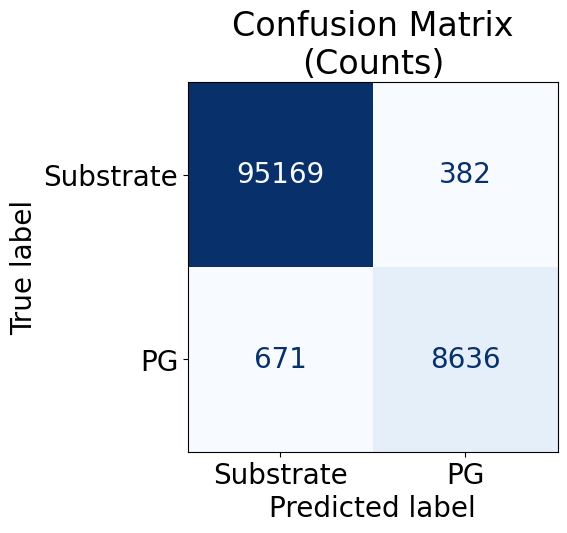

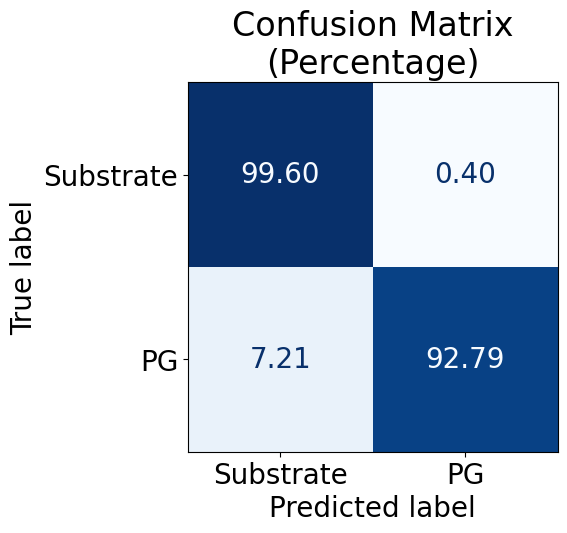

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     95551
           1       0.96      0.93      0.94      9307

    accuracy                           0.99    104858
   macro avg       0.98      0.96      0.97    104858
weighted avg       0.99      0.99      0.99    104858



In [8]:
# ----- Absolute Confusion Matrix -----
cm_abs = confusion_matrix(y_test, y_pred_test)
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=["Substrate", "PG"])
fig, ax = plt.subplots()
im = disp_abs.plot(cmap='Blues', ax=ax, colorbar=False).im_
plt.title('Confusion Matrix\n(Counts)')
plt.show()

# ----- Row-wise Percentage Confusion Matrix -----
cm_norm = confusion_matrix(y_test, y_pred_test, normalize='true') * 100
disp_percent = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Substrate", "PG"])
fig, ax = plt.subplots()
im = disp_percent.plot(cmap='Blues', ax=ax, values_format=".2f", colorbar=False).im_
plt.title('Confusion Matrix\n(Percentage)')
plt.show()

print(classification_report(y_test, y_pred_test))

### Show the predicted output image from the particle/substrate classifier on the test/train dataset 

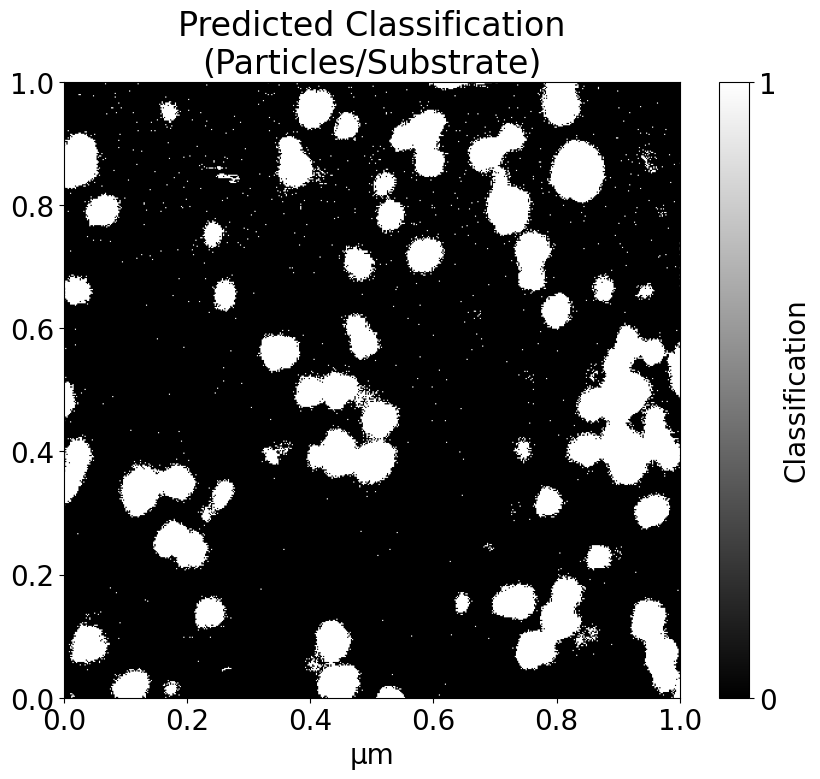

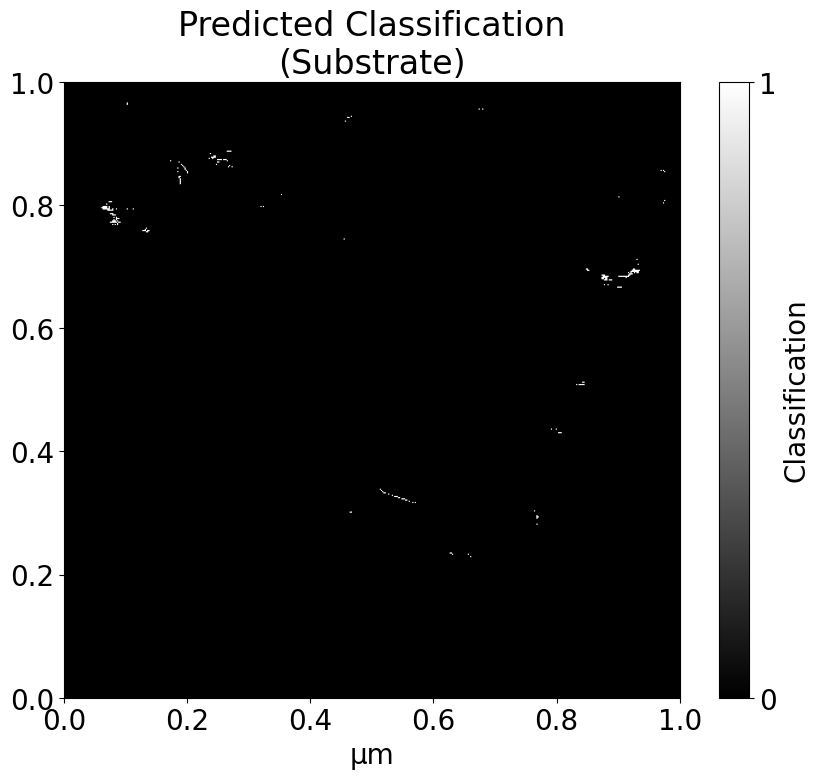

In [9]:
###----- Examne model on PG/Substrate Training Data -----###
# Scale the data using the same scaler as the training data
X_train_particles = df_data_train_particles.loc[:, selected_features]

# Scale the data using the same scaler as the training data
X_train_particles_scaled = scaler_1.transform(X_train_particles)

# Fit data using the trained unsupervised model
y_pred_train_particles = kmeans_classifier_1.predict(X_train_particles_scaled)

# Define the square image size
image_size = int(math.sqrt(len(y_pred_train_particles))) # assuming a square image

# Reshape the predicted output labels into an image
image_pred_train_particles = y_pred_train_particles.reshape(image_size, image_size)

# Plot the image
plot_afm_classification(
    image_pred_train_particles,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Particles/Substrate)"
)

###----- Examine Model on Substrate Training Data -----###
X_train_substrate = df_data_train_substrate.loc[:, selected_features]

# Scale the data using the same scaler as the trianing data
X_train_substrate = df_data_train_substrate.loc[:, selected_features]
X_train_substrate_scaled = scaler_1.transform(X_train_substrate)

# Fit data using the trained unsupervised model
y_pred_train_substrate = kmeans_classifier_1.predict(X_train_substrate_scaled)

# Define the square image size
image_size = int(math.sqrt(len(y_pred_train_substrate))) # assuming a square image

# Reshape the predicted output labels into an image
image_pred_train_substrate = y_pred_train_substrate.reshape(image_size, image_size)

# Plot the image
plot_afm_classification(
    image_pred_train_substrate,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Substrate)"
)

### Remove small clusters from particle/substrate image

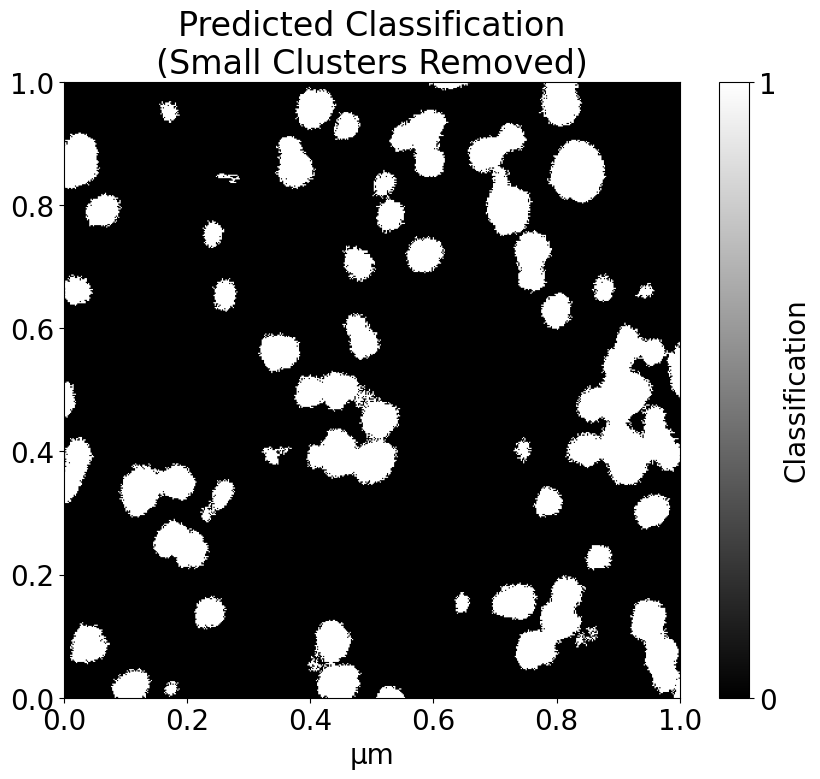

Total number of pixels with value 1 before changes: 44927
Total number of pixels whose values were changed: 1331
Percent of PG pixels changed: 2.9625837469673026%


In [10]:
# Set the maximum number of pixels in a cluster to remove
threshold = 35 

# Define the image of interest
image = image_pred_train_particles

# Create a new image with the same dimensions as the original image
new_image_training_particles = np.copy(image)

# Label regions of connected pixels with values > 1 (i.e. not the substrate)
labeled_image = label(new_image_training_particles)

# Get properties of each connected region
regions = regionprops(labeled_image)

# Iterate through each region and examine area of region
# If region area is less than threshold change classification value to 0
for region in regions:
    if region.area < threshold:
        for coord in region.coords:
            new_image_training_particles[coord[0], coord[1]] = 0
                          
# Plot the new image
plot_afm_classification(
    new_image_training_particles,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Small Clusters Removed)"
)

# Calculate the total number of pixels with value 1 in the original image
total_white_pixels = np.sum(image == 1)

# Calculate the total number of changed pixels
changed_pixels = np.sum(image != new_image_training_particles)

# Calculate the percent of changed pixels in terms of all PG pixels
changed_pixels_percent = 100*changed_pixels/total_white_pixels

# Print the results of the changes
print(f"Total number of pixels with value 1 before changes: {total_white_pixels}")
print(f"Total number of pixels whose values were changed: {changed_pixels}")
print(f"Percent of PG pixels changed: {changed_pixels_percent}%")

## Inner Particle Structure ML Classifer

### Create DataFrame of selected feature values for each force-distance curve within particles only

In [11]:
# Manual labels are 0, 1, or 2 to indicate substrate, outer region, inner region respectively
# Import manual classification labels
y_output = new_image_training_particles.flatten()
# Create mask from classifications from output of particle/substrate classifier
mask = (y_output != 0)
# Use mask to filter data to include only that manually labelled as corresponding to particles
X_train_filtered = X_train_particles[mask]

### Train/Test the Internal Particle Structure ML Classifier

In [12]:
# Change all pixels classified with a target_feature of nonzero to 1 (i.e. change 2's to 1's)
y_2 = df_data_train_particles[target_feature] # populate with manual labels
y_2_filtered = y_2[mask] # filter only those classified as particle pixels from the particle/substrate ML classifier
y_2_filtered = y_2_filtered.replace(0, 1) # replace any manual labels of 0 with 1
y_2_filtered = y_2_filtered-1 # reduce all manual labels by 1 (i.e. 1-->0, 2-->1)

# Train-test split with 90% of the data for training
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_train_filtered, y_2_filtered, test_size = 0.1, random_state = 17)

# Scale the data 
scaler_2 = MinMaxScaler()
X_train_2_scaled = scaler_2.fit_transform(X_train_2)

# Construct KMeans classifier
number_of_classes_2 = 2
kmeans_classifier_2 = KMeans(n_clusters=number_of_classes_2, random_state=17)

# Train the classifier
kmeans_classifier_2.fit(X_train_2_scaled)

# Extract labels and the Young's modulus column
labels = kmeans_classifier_2.labels_
feature_check = X_train_2["Recovery from 50% to 25% of max force"].values

# Compute mean Young's modulus for each cluster
medians = [np.median(feature_check[labels == i]) for i in range(kmeans_classifier_2.n_clusters)]

# Check if clusters are labelled outer region = 0, inner region = 1
# The median of the feature_check feature value should be larger for inner_region = 1 (determined from supervised ML classifier)
if medians[0] > medians[1]:
    print("Predicted cluster labels switched")
    # Swap cluster centers
    kmeans_classifier_2.cluster_centers_[[0, 1]] = kmeans_classifier_2.cluster_centers_[[1, 0]]

# Predict on the test set
X_test_2_scaled = scaler_2.transform(X_test_2) # Scale the test data
y_pred_kmeans_2 = kmeans_classifier_2.predict(X_test_2_scaled)

# Display the number of pixels classified in the training set
print("Total Pixels Classified:", len(y_train_2))

# Evaluate the classifier
accuracy_kmeans_2 = accuracy_score(y_test_2, y_pred_kmeans_2)
print("KMeans Testing Accuracy:", accuracy_kmeans_2)

print('Inner Particle Structure ML Classifier sucessfully trained')

Predicted cluster labels switched
Total Pixels Classified: 39236
KMeans Testing Accuracy: 0.6864678899082569
Inner Particle Structure ML Classifier sucessfully trained


### Evaluate the accuracy of the Inner Particle Structure ML Classifier on the test data

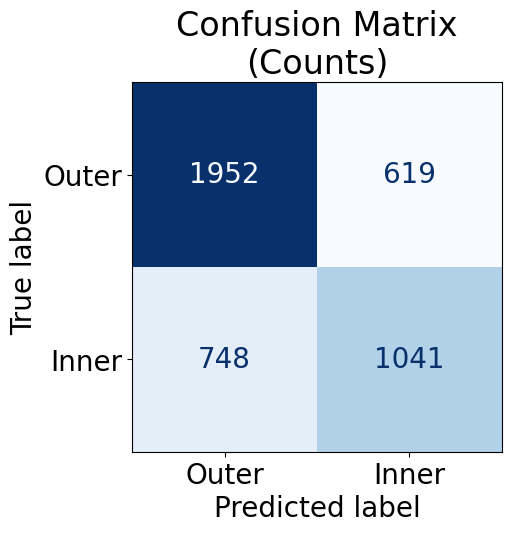

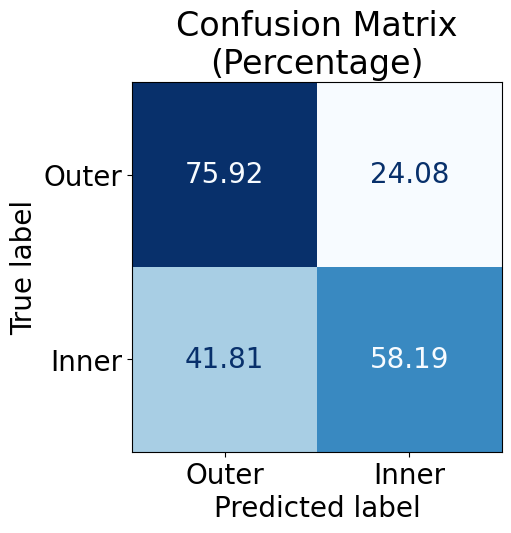

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      2571
           1       0.63      0.58      0.60      1789

    accuracy                           0.69      4360
   macro avg       0.68      0.67      0.67      4360
weighted avg       0.68      0.69      0.68      4360



In [13]:
# ----- Absolute Confusion Matrix -----#
cm_abs_2 = confusion_matrix(y_test_2, y_pred_kmeans_2)
disp_abs_2 = ConfusionMatrixDisplay(confusion_matrix=cm_abs_2, display_labels=["Outer", "Inner"])
fig, ax = plt.subplots()
im = disp_abs_2.plot(cmap='Blues', ax=ax, colorbar=False).im_
plt.title('Confusion Matrix\n(Counts)')
plt.show()

# ----- Row-wise Percentage Confusion Matrix -----#
cm_norm_2 = confusion_matrix(y_test_2, y_pred_kmeans_2, normalize='true') * 100
disp_percent_2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm_2, display_labels=["Outer", "Inner"])
fig, ax = plt.subplots()
im = disp_percent_2.plot(cmap='Blues', ax=ax, values_format=".2f", colorbar=False).im_
plt.title('Confusion Matrix\n(Percentage)')
plt.show()

print(classification_report(y_test_2, y_pred_kmeans_2))

### Show the predicted output image from the Inner Particle Structure ML classifier on the train/test dataset 

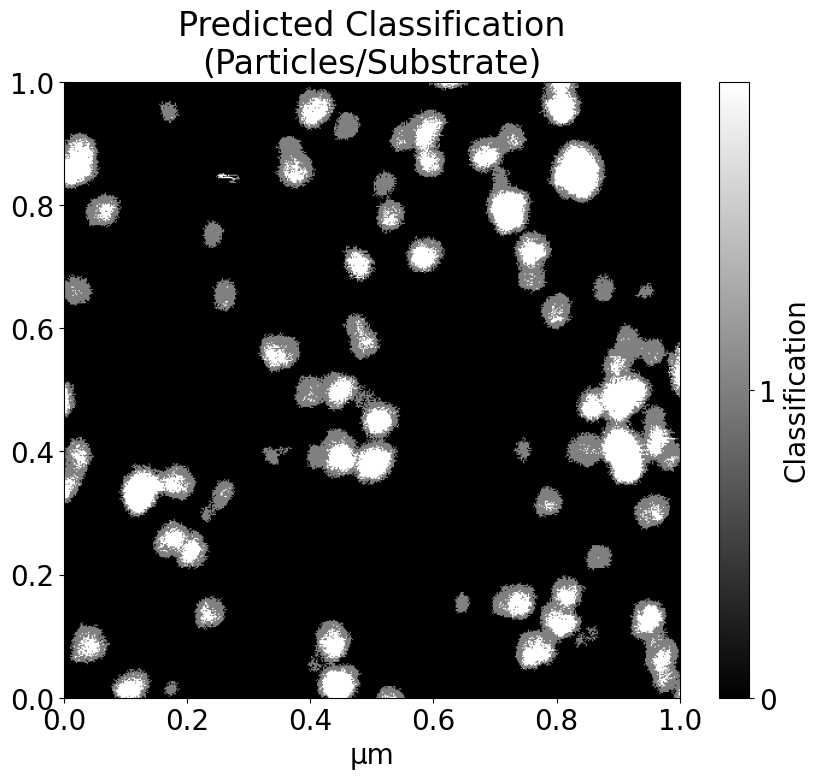

In [14]:
# Scale the filtered training/testing data
X_filtered_scaled = scaler_2.transform(X_train_filtered)

# Fit particle regions in test/train data using trained Inner Particle Structure ML Classifier
y_pred_train_particles_filtered = kmeans_classifier_2.predict(X_filtered_scaled)

# Increase all labels by 1 to make them 1 and 2 (instead of 0 and 1)
y_pred_train_particles_filtered = y_pred_train_particles_filtered + 1
y_pred_train_particles_filtered_combined = np.copy(y_output) # copy the output from the first classifier
y_pred_train_particles_filtered_combined[mask] = y_pred_train_particles_filtered # update the pixels according to the second clssifier

#----- Plot the classification image -----#
# Define the image size
image_size = int(math.sqrt(len(X_train_particles))) # assuming a square image
# Reshape the predicted output labels into an image
image_pred_train_particles_filtered = y_pred_train_particles_filtered_combined.reshape(image_size, image_size)
# Plot the image
plot_afm_classification(
    image_pred_train_particles_filtered,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Particles/Substrate)"
)

## Save Trained Supervised ML Classifiers, Scalers, and Feature List

In [15]:
# Create the full file paths for the trained models and scalers
model_1_filename = os.path.join(output_folder, 'kmeans_classifier_particle_substrate.pkl')
model_2_filename = os.path.join(output_folder, 'kmeans_classifier_inner_particle_structure.pkl')
scaler_1_filename = os.path.join(output_folder, 'kmeans_scaler_particle_substrate.pkl')
scaler_2_filename = os.path.join(output_folder, 'kmeans_scaler_inner_particle_structure.pkl')

# Save the classifiers and scalers
joblib.dump(kmeans_classifier_1, model_1_filename)
joblib.dump(kmeans_classifier_2, model_2_filename)
joblib.dump(scaler_1, scaler_1_filename)
joblib.dump(scaler_2, scaler_2_filename)

print(f"Trained Unsupervised ML classifiers saved to: {output_folder}")
print(f"Trained Scalers saved to: {output_folder}")

# Save selected features
features_filename = os.path.join(output_folder, 'kmeans_selected_features.json')
with open(features_filename, 'w') as f:
    json.dump(selected_features, f)

print(f"Selected features saved to: {output_folder}")



# Calculate the total run time
end_time = time.time()
elapsed_time = end_time - start_time

print("Total Run Time = ", elapsed_time, "seconds")

Trained Unsupervised ML classifiers saved to: .
Trained Scalers saved to: .
Selected features saved to: .
Total Run Time =  6.685441493988037 seconds
